In [1]:
from __future__ import annotations

import argparse
import importlib.util
import logging
import sys
import time
import types
from pathlib import Path
from tqdm import tqdm

from src.utils import pmf_utils
import pandas as pd
import matplotlib.pyplot as plt
import importlib, src.ddm.ddm

importlib.reload(src.ddm.ddm)

import numpy as np
import torch
import pickle

from config import dir_config

from src.ddm.utils import build_stimulus, get_job, build_grid, prepare_data, load_model

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

In [2]:
# change directory to project root
import os

cwd = Path.cwd()
if cwd.name == "notebooks":
    os.chdir(cwd.parent)

from scripts.ddm.ddm_fitting import DDMModel

In [3]:
processed_dir = Path(dir_config.data.processed)
ddm_dir = processed_dir / "ddm"

behavior_df = pd.read_csv(ddm_dir / "behavior_data.csv")

In [4]:
# find all folders in ddm_dir
model_folders = [f for f in ddm_dir.iterdir() if f.is_dir()]
print("DDM folders found:", model_folders)

DDM folders found: [PosixPath('/mnt/pd-data/processed/ddm/leak-0_tc-1'), PosixPath('/mnt/pd-data/processed/ddm/leak-1_tc-1'), PosixPath('/mnt/pd-data/processed/ddm/plain_ddm'), PosixPath('/mnt/pd-data/processed/ddm/leak-0_tc-0'), PosixPath('/mnt/pd-data/processed/ddm/leak-1_tc-0')]


In [5]:
session_ids = set(behavior_df["session_id"].unique())
grid = build_grid(behavior_df)
job_lookup = {job_id: get_job(grid, job_id) for job_id in range(len(grid))}
stem_to_job_id = {
    (
        job["session_id"],
        job["color"],
        job["enable_leak"],
        job["enable_time_constant"],
        job["enable_sv"],
        job["enable_sz"],
    ): job_id
    for job_id, job in job_lookup.items()
}

MODEL_VARIANTS = [
    {"name": "leak-0_tc-0", "enable_leak": False, "enable_time_constant": False, "enable_sv": True, "enable_sz": True},
    {"name": "leak-0_tc-1", "enable_leak": False, "enable_time_constant": True, "enable_sv": True, "enable_sz": True},
    {"name": "leak-1_tc-0", "enable_leak": True, "enable_time_constant": False, "enable_sv": True, "enable_sz": True},
    {"name": "leak-1_tc-1", "enable_leak": True, "enable_time_constant": True, "enable_sv": True, "enable_sz": True},
    {"name": "plain_ddm", "enable_leak": False, "enable_time_constant": False, "enable_sv": False, "enable_sz": False},
]

missing_job_ids = set()
failed_job_ids = set()

for variant in MODEL_VARIANTS:
    sub_dir = ddm_dir / variant["name"]
    leak = variant["enable_leak"]
    tc = variant["enable_time_constant"]
    sv = variant["enable_sv"]
    sz = variant["enable_sz"]

    expected = {(sid, block, leak, tc, sv, sz) for sid in session_ids for block in [0, 1]}

    found = set()
    for model in sub_dir.rglob("*.pkl"):
        try:
            session = model.stem.split("_color_")[0]
            block = int(model.stem.split("_color_")[1])
            found.add((session, block, leak, tc, sv, sz))
        except Exception as e:
            print(f"[PARSE ERROR] {model}: {e}")

    missing = expected - found
    extra = found - expected

    print(f"\n=== {variant['name']} ===")
    print(f"Total files: {len(list(sub_dir.rglob('*.pkl')))}\tExpected: {len(expected)}\tMissing: {len(missing)}\tExtra: {len(extra)}")

    if missing:
        print("\nMISSING DETAILS:")
        for m in sorted(missing):
            job_id = stem_to_job_id.get(m)
            print(f"{m} -> job_id={job_id}")
            if job_id is not None:
                missing_job_ids.add(job_id)

print("\n=== FITTING SUMMARY ===")
for variant in MODEL_VARIANTS:
    model_path = ddm_dir / variant["name"]
    leak = variant["enable_leak"]
    tc = variant["enable_time_constant"]
    sv = variant["enable_sv"]
    sz = variant["enable_sz"]
    failed = list(model_path.glob("*.FAILED.json"))
    if failed:
        print(f"Model {variant['name']} has {len(failed)} failed fits:")
        for f in failed:
            base = f.stem.removesuffix(".FAILED")
            session, color = base.split("_color_")[0], int(base.split("_color_")[1])
            job_id = stem_to_job_id.get((session, color, leak, tc, sv, sz))
            print(f"  {f.name} -> job_id={job_id}")
            if job_id is not None:
                print(f"Failed job ID: {job_id}, variant: {variant['name']}, session: {session}, color: {color}")
                failed_job_ids.add(job_id)
    else:
        print(f"Model {variant['name']} has no failed fits.")


=== leak-0_tc-0 ===
Total files: 200	Expected: 200	Missing: 0	Extra: 0

=== leak-0_tc-1 ===
Total files: 200	Expected: 200	Missing: 0	Extra: 0

=== leak-1_tc-0 ===
Total files: 200	Expected: 200	Missing: 0	Extra: 0

=== leak-1_tc-1 ===
Total files: 200	Expected: 200	Missing: 0	Extra: 0

=== plain_ddm ===
Total files: 200	Expected: 200	Missing: 0	Extra: 0

=== FITTING SUMMARY ===
Model leak-0_tc-0 has no failed fits.
Model leak-0_tc-1 has no failed fits.
Model leak-1_tc-0 has no failed fits.
Model leak-1_tc-1 has no failed fits.
Model plain_ddm has no failed fits.


In [6]:
print("\n=== SUMMARY ===")
print("Missing job IDs:", sorted(missing_job_ids))
print("Failed job IDs:", sorted(failed_job_ids))
rerun_job_ids = missing_job_ids.union(failed_job_ids)
print("Rerun job IDs:", ",".join(str(j) for j in sorted(rerun_job_ids)))


=== SUMMARY ===
Missing job IDs: []
Failed job IDs: []
Rerun job IDs: 


# Session Wise Model Fits

In [7]:
# calculate cumulative likelihood for all model types
cumulative_likelihoods = {}
aic_values = {}
bic_values = {}

# free params: ndt, a, z, drift_gain, drift_offset (+sv, +sz, +leak_rate, +time_constant where enabled)
PARAM_COUNTS = {
    "leak-0_tc-0": 7,  # base 5 + sv + sz
    "leak-0_tc-1": 8,  # + time_constant
    "leak-1_tc-0": 8,  # + leak_rate
    "leak-1_tc-1": 9,  # + leak_rate + time_constant
    "plain_ddm": 5,  # base 5 only
}

for variant in MODEL_VARIANTS:
    model_type = variant["name"]
    model_path = ddm_dir / model_type

    pkl_files = list(model_path.glob("*.pkl"))

    total_nll = 0
    for pkl_file in tqdm(pkl_files, desc=f"Loading {model_type} models", unit="file"):
        try:
            model = load_model(pkl_file)
            total_nll += model["results"]["likelihood"]
        except Exception as e:
            print(f"Error loading {pkl_file}: {e}")

    k = PARAM_COUNTS[model_type]
    cumulative_likelihoods[model_type] = np.round(total_nll)
    aic_values[model_type] = 2 * k + 2 * np.round(total_nll)
    bic_values[model_type] = np.round(k * np.log(len(behavior_df)) + 2 * np.round(total_nll))

best_likelihood_model = min(cumulative_likelihoods, key=cumulative_likelihoods.get)
best_aic_model = min(aic_values, key=aic_values.get)
best_bic_model = min(bic_values, key=bic_values.get)

if best_likelihood_model == best_aic_model == best_bic_model:
    print(f"Best model by likelihood, AIC, and BIC: {best_likelihood_model}")
else:
    print(f"Best model by likelihood: {best_likelihood_model}")
    print(f"Best model by AIC:        {best_aic_model}")
    print(f"Best model by BIC:        {best_bic_model}")

Loading plain_ddm models: 100%|██████████| 200/200 [01:46<00:00,  1.88file/s]

Best model by likelihood, AIC, and BIC: leak-1_tc-1


In [8]:
print("=== MODEL COMPARISON ===")
print(f"{'Model':<15} {'Cumulative NLL':<20} {'AIC':<10} {'BIC':<10}")
for model in cumulative_likelihoods.keys():
    print(f"{model:<15} {cumulative_likelihoods[model]:<20} {aic_values[model]:<10} {bic_values[model]:<10}")

=== MODEL COMPARISON ===
Model           Cumulative NLL       AIC        BIC       
leak-0_tc-0     18772.0              37558.0    37621.0   
leak-0_tc-1     16803.0              33622.0    33694.0   
leak-1_tc-0     18788.0              37592.0    37664.0   
leak-1_tc-1     16747.0              33512.0    33593.0   
plain_ddm       20296.0              40602.0    40647.0   


# Plot behavior fit for each model

In [9]:
from __future__ import annotations

import logging
from pathlib import Path
from tqdm import tqdm

from src.utils import pmf_utils
import pandas as pd
import matplotlib.pyplot as plt
import importlib, src.ddm.ddm

importlib.reload(src.ddm.ddm)

import numpy as np
import torch
import pickle
from pptx import Presentation
from pptx.util import Inches, Pt
from pptx.enum.text import PP_ALIGN
import io

from config import dir_config

from src.ddm.utils import build_stimulus, prepare_data, load_model

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

In [ ]:
def plot_ddm_fit(data, sim, title="DDM Fit"):
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 4))

    cohs_sorted = sorted(data["signed_coherence"].unique())

    def summarize(df):
        p_upper = []
        mean_rt_upper, sem_rt_upper = [], []
        mean_rt_lower, sem_rt_lower = [], []
        for c in cohs_sorted:
            subset = df[df["signed_coherence"] == c].dropna(subset=["rt", "choice"])
            p_upper.append((subset["choice"] == 1).mean() if len(subset) > 0 else np.nan)
            upper = subset[subset["choice"] == 1]["rt"]
            lower = subset[subset["choice"] == 0]["rt"]
            mean_rt_upper.append(upper.mean() if len(upper) > 0 else np.nan)
            sem_rt_upper.append(upper.sem() if len(upper) > 0 else np.nan)
            mean_rt_lower.append(lower.mean() if len(lower) > 0 else np.nan)
            sem_rt_lower.append(lower.sem() if len(lower) > 0 else np.nan)
        return np.array(p_upper), np.array(mean_rt_upper), np.array(sem_rt_upper), np.array(mean_rt_lower), np.array(sem_rt_lower)

    def get_subset(df, outcome):
        if outcome == "correct":
            return df[((df["choice"] == 1) & (df["signed_coherence"] > 0)) | ((df["choice"] == 0) & (df["signed_coherence"] < 0)) | (df["signed_coherence"] == 0)]
        elif outcome == "incorrect":
            return df[((df["choice"] == 0) & (df["signed_coherence"] > 0)) | ((df["choice"] == 1) & (df["signed_coherence"] < 0)) | (df["signed_coherence"] == 0)]
        else:
            raise ValueError("Outcome must be 'correct' or 'incorrect'")

    def summarize2(df, outcome):
        df = get_subset(df, outcome)
        mean_rt, sem_rt = [], []
        for c in cohs_sorted:
            subset = df[df["signed_coherence"] == c].dropna(subset=["rt", "choice"])
            mean_rt.append(subset["rt"].mean() if len(subset) > 0 else np.nan)
            sem_rt.append(subset["rt"].sem() if len(subset) > 0 else np.nan)
        return np.array(mean_rt), np.array(sem_rt)

    def plot_chromo_sem(x, y, yerr, color, label, ax):
        ax.plot(x, y, "o-", color=color, label=label)
        ax.fill_between(x, y - yerr, y + yerr, color=color, alpha=0.2)

    d_p_upper, d_mean_rt_upper, d_sem_rt_upper, d_mean_rt_lower, d_sem_rt_lower = summarize(data)
    s_p_upper, s_mean_rt_upper, s_sem_rt_upper, s_mean_rt_lower, s_sem_rt_lower = summarize(sim)

    # Psychometric function
    ax1.plot(cohs_sorted, d_p_upper, "o-", color="steelblue", label="Data")
    ax1.plot(cohs_sorted, s_p_upper, "-", color="tomato", label="Model")
    ax1.axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
    ax1.axvline(0.0, color="gray", linestyle="--", linewidth=0.8)
    ax1.set(xlabel="Coherence", ylabel="P(upper boundary)", title="Psychometric Function", ylim=(0, 1))

    d_mean_rt_correct, d_sem_rt_correct = summarize2(data, "correct")
    d_mean_rt_incorrect, d_sem_rt_incorrect = summarize2(data, "incorrect")
    s_mean_rt_correct, s_sem_rt_correct = summarize2(sim, "correct")
    s_mean_rt_incorrect, s_sem_rt_incorrect = summarize2(sim, "incorrect")

    plot_chromo_sem(cohs_sorted, d_mean_rt_correct, d_sem_rt_correct, color="steelblue", label="Data", ax=ax2)
    plot_chromo_sem(cohs_sorted, s_mean_rt_correct, s_sem_rt_correct, color="tomato", label="Model", ax=ax2)
    plot_chromo_sem(cohs_sorted, d_mean_rt_incorrect, d_sem_rt_incorrect, color="steelblue", label="Data", ax=ax3)
    plot_chromo_sem(cohs_sorted, s_mean_rt_incorrect, s_sem_rt_incorrect, color="tomato", label="Model", ax=ax3)

    ax2.set(xlabel="Coherence", ylabel="Mean RT (s)", title="Chronometric - Correct Trials")
    ax3.set(xlabel="Coherence", ylabel="Mean RT (s)", title="Chronometric - Incorrect Trials")

    y_min = min(ax2.get_ylim()[0], ax3.get_ylim()[0])
    y_max = max(ax2.get_ylim()[1], ax3.get_ylim()[1])
    ax2.set_ylim(y_min, y_max)
    ax3.set_ylim(y_min, y_max)

    ax3.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

    for ax in [ax1, ax2, ax3]:
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    plt.suptitle(title)
    plt.tight_layout()
    return fig


def get_simulated_data(model_struct, behavior_df):
    session_data = prepare_data(
        behavior_df,
        session_id=model_struct["job"]["session_id"],
        color=int(model_struct["job"]["color"]),
    )
    stimulus = build_stimulus(session_data)
    sim_data = model_struct["model"].simulate(stimulus=stimulus, params=model_struct["results"]["parameters"], n_reps=1)
    return session_data, pd.DataFrame(sim_data)


import seaborn as sns
from scipy.stats import ttest_rel


def load_and_plot_model(model_dir, behavior_df, plot_individual_fits=False):
    fitted_params = []
    s_data, d_data = [], []

    for idx, model_path in tqdm(enumerate(model_dir.rglob("*.pkl")), desc=f"Processing models in {model_dir.name}", unit="file"):
        try:
            model_struct = load_model(model_path)
            parameters = model_struct["results"]["parameters"]
            session_id = model_struct["job"]["session_id"]
            color = model_struct["job"]["color"]
            fitted_params.append({"session_id": session_id, "color": color, **parameters})
        except Exception as e:
            print(f"Error loading {model_path}: {e}")
            continue

        d_session_data, s_session_data = get_simulated_data(model_struct, behavior_df)
        d_session_data["session_id"] = s_session_data["session_id"] = session_id
        d_session_data["color"] = s_session_data["color"] = color
        d_data.append(d_session_data)
        s_data.append(s_session_data)

        if plot_individual_fits:
            fig = plot_ddm_fit(data=d_session_data, sim=s_session_data, title=f"DDM Fit: {session_id}_prior_block_{color}")
            plt.show()

    d_data = pd.concat(d_data, ignore_index=True)
    s_data = pd.concat(s_data, ignore_index=True)
    fitted_params = pd.DataFrame(fitted_params)

    fit_fig = plot_ddm_fit(data=d_data, sim=s_data, title=f"DDM Fit: {model_dir.name} (All Sessions Combined)")
    return fit_fig, fitted_params


def plot_param_comparison(fitted_params, model_name=""):
    from matplotlib.patches import Patch

    eq_color, uq_color = "gray", "black"

    ignore_cols = ["session_id", "color", "dt", "variance"]

    equal_block = fitted_params.groupby("session_id").apply(lambda df: df[df["color"] == 0].iloc[0] if len(df) == 2 else None).dropna().reset_index(drop=True)
    unequal_block = fitted_params.groupby("session_id").apply(lambda df: df[df["color"] == 1].iloc[0] if len(df) == 2 else None).dropna().reset_index(drop=True)

    param_cols = [c for c in fitted_params.columns if c not in ignore_cols]
    fig, axs = plt.subplots(1, len(param_cols), figsize=(5 * len(param_cols), 5))
    if len(param_cols) == 1:
        axs = [axs]

    for ax_idx, col in enumerate(param_cols):
        t_stat, t_p_value = ttest_rel(equal_block[col], unequal_block[col])
        means = [equal_block[col].mean(), unequal_block[col].mean()]
        sems = [equal_block[col].sem(), unequal_block[col].sem()]

        sns.barplot(x=["Equal Prior", "Unequal Prior"], y=means, yerr=sems, palette=[eq_color, uq_color], ax=axs[ax_idx])
        p_str = f"{t_p_value:.3f}" if not np.isnan(t_p_value) else "n/a"
        axs[ax_idx].set_ylabel(col)
        axs[ax_idx].set_title(f"{col}\np = {p_str}")
        axs[ax_idx].spines["top"].set_visible(False)
        axs[ax_idx].spines["right"].set_visible(False)

    handles = [Patch(color=eq_color, label="Equal Prior"), Patch(color=uq_color, label="Unequal Prior")]
    axs[-1].legend(handles=handles, loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0, frameon=False)

    if model_name:
        plt.suptitle(model_name)
    plt.tight_layout()
    return fig


def save_figures_to_pptx(figures_list, param_figures_list, model_names, output_path="ddm_results.pptx"):
    prs = Presentation()
    prs.slide_width = Inches(13.33)
    prs.slide_height = Inches(7.5)

    blank_layout = prs.slide_layouts[6]

    for model_name, fit_fig, param_fig in zip(model_names, figures_list, param_figures_list):
        slide = prs.slides.add_slide(blank_layout)

        # slide title
        txBox = slide.shapes.add_textbox(Inches(0.3), Inches(0.05), Inches(12.7), Inches(0.4))
        tf = txBox.text_frame
        tf.text = model_name
        tf.paragraphs[0].alignment = PP_ALIGN.CENTER
        tf.paragraphs[0].runs[0].font.size = Pt(20)
        tf.paragraphs[0].runs[0].font.bold = True

        # fit figure — top half
        buf_fit = io.BytesIO()
        fit_fig.savefig(buf_fit, format="png", dpi=150, bbox_inches="tight")
        buf_fit.seek(0)
        slide.shapes.add_picture(buf_fit, Inches(0.3), Inches(0.5), width=Inches(12.7))

        # param figure — bottom half
        buf_param = io.BytesIO()
        param_fig.savefig(buf_param, format="png", dpi=150, bbox_inches="tight")
        buf_param.seek(0)
        slide.shapes.add_picture(buf_param, Inches(0.3), Inches(4.0), width=Inches(12.7))

    prs.save(output_path)
    print(f"Saved {len(prs.slides)} slides → {output_path}")

In [12]:
processed_dir = Path(dir_config.data.processed)
ddm_dir = processed_dir / "ddm"

behavior_df = pd.read_csv(ddm_dir / "behavior_data.csv")

models = [model_dir for model_dir in ddm_dir.glob("*") if model_dir.is_dir()]
models

[PosixPath('/mnt/pd-data/processed/ddm/leak-0_tc-1'),
 PosixPath('/mnt/pd-data/processed/ddm/leak-1_tc-1'),
 PosixPath('/mnt/pd-data/processed/ddm/plain_ddm'),
 PosixPath('/mnt/pd-data/processed/ddm/leak-0_tc-0'),
 PosixPath('/mnt/pd-data/processed/ddm/leak-1_tc-0')]

Processing models in leak-0_tc-1: 200file [01:41,  1.97file/s]
Processing models in leak-1_tc-1: 200file [01:41,  1.97file/s]
Processing models in plain_ddm: 200file [01:41,  1.96file/s]
Processing models in leak-0_tc-0: 200file [02:02,  1.63file/s]
Processing models in leak-1_tc-0: 200file [01:50,  1.82file/s]


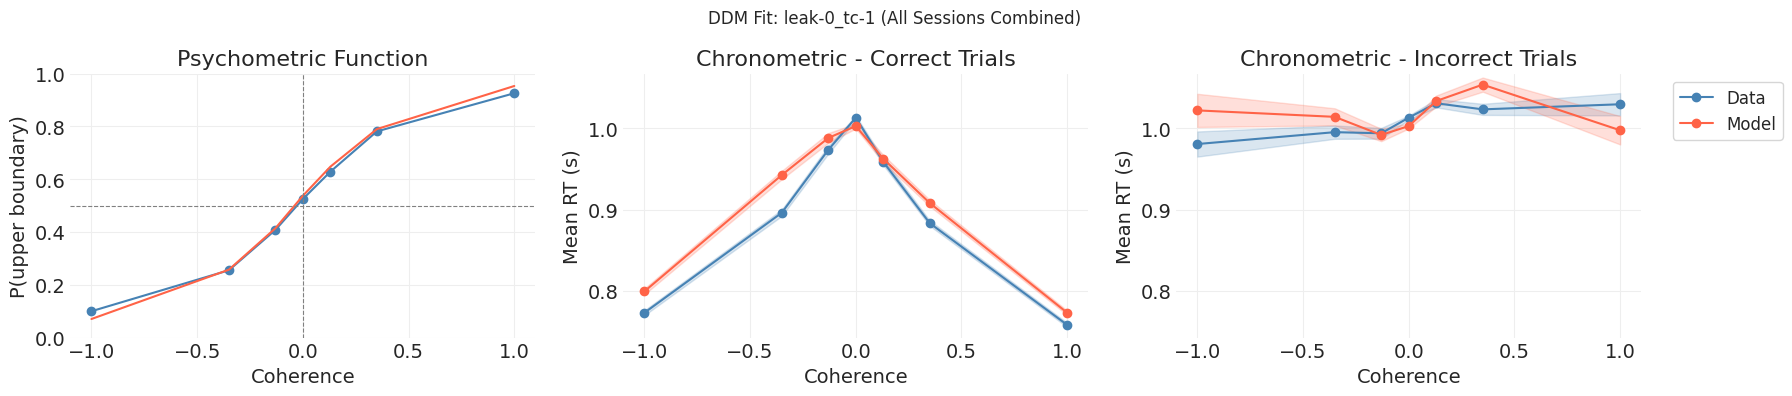

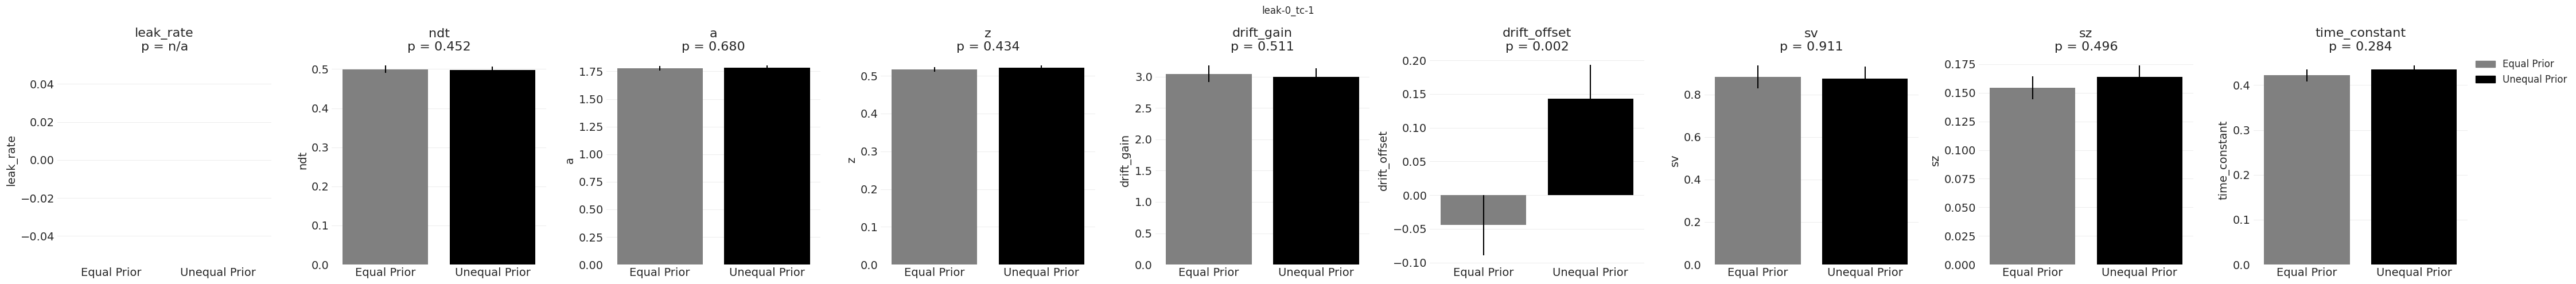

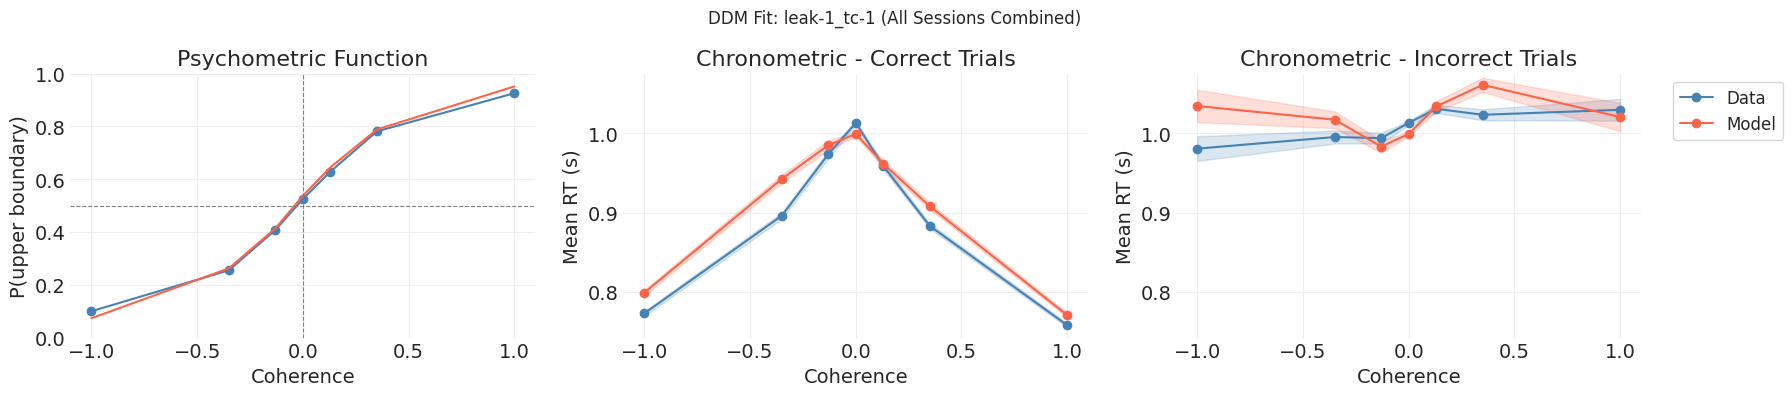

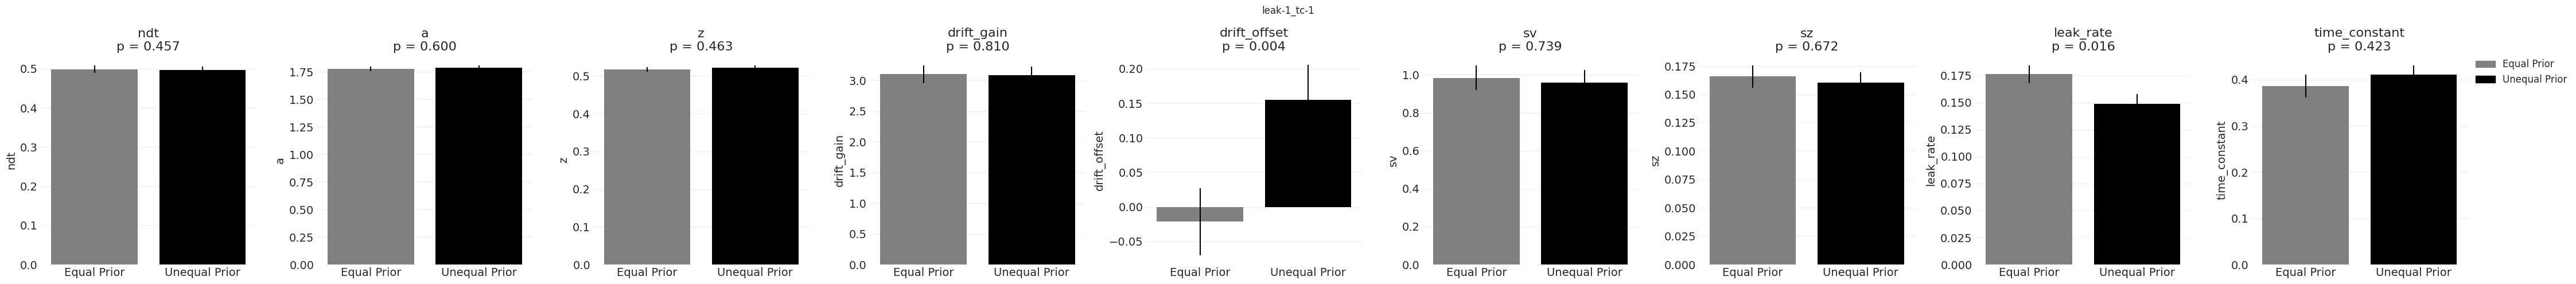

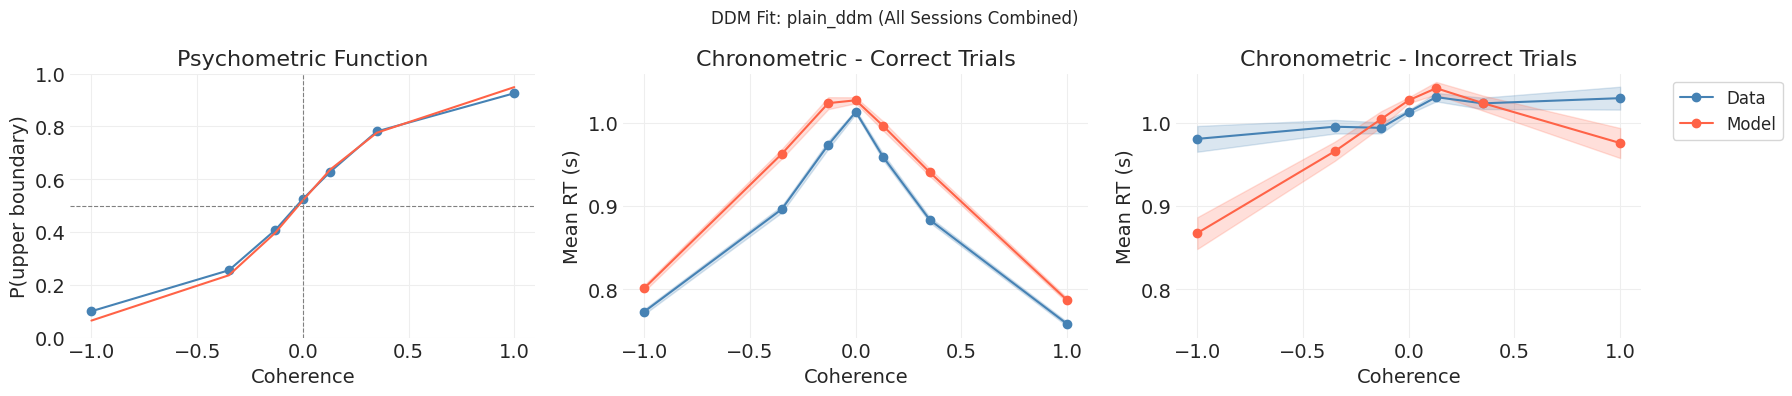

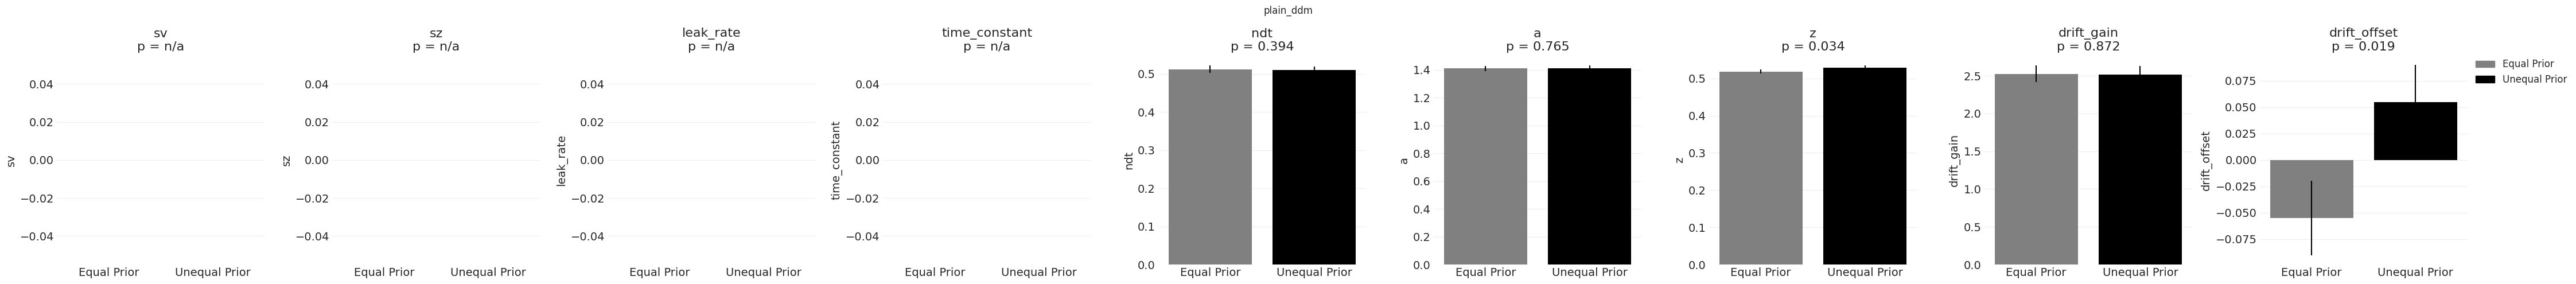

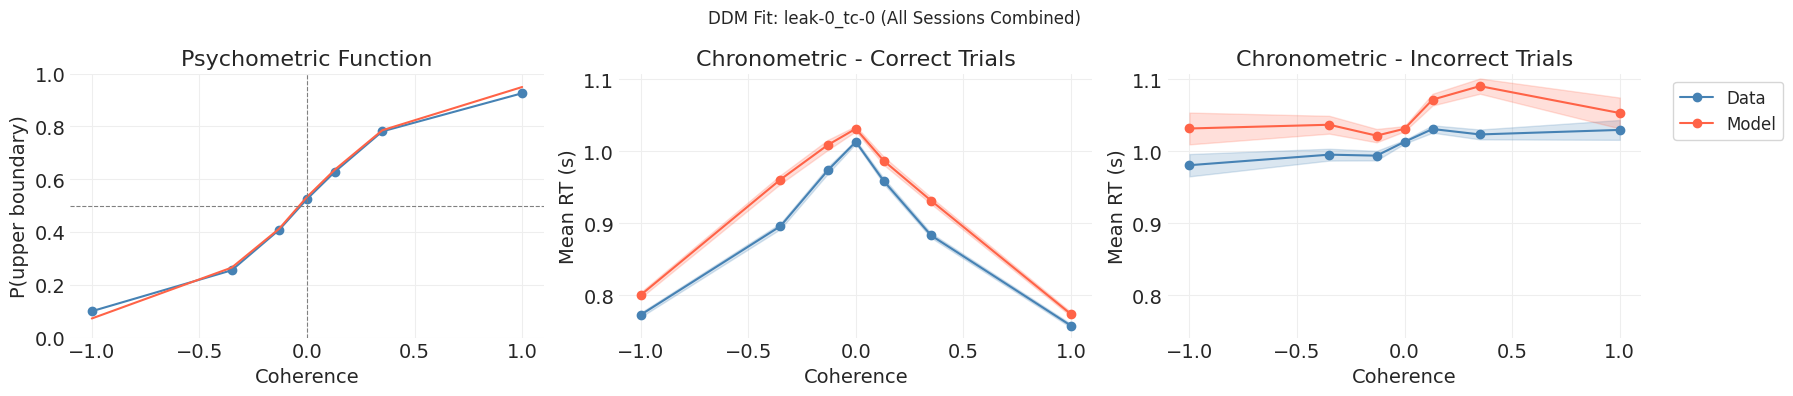

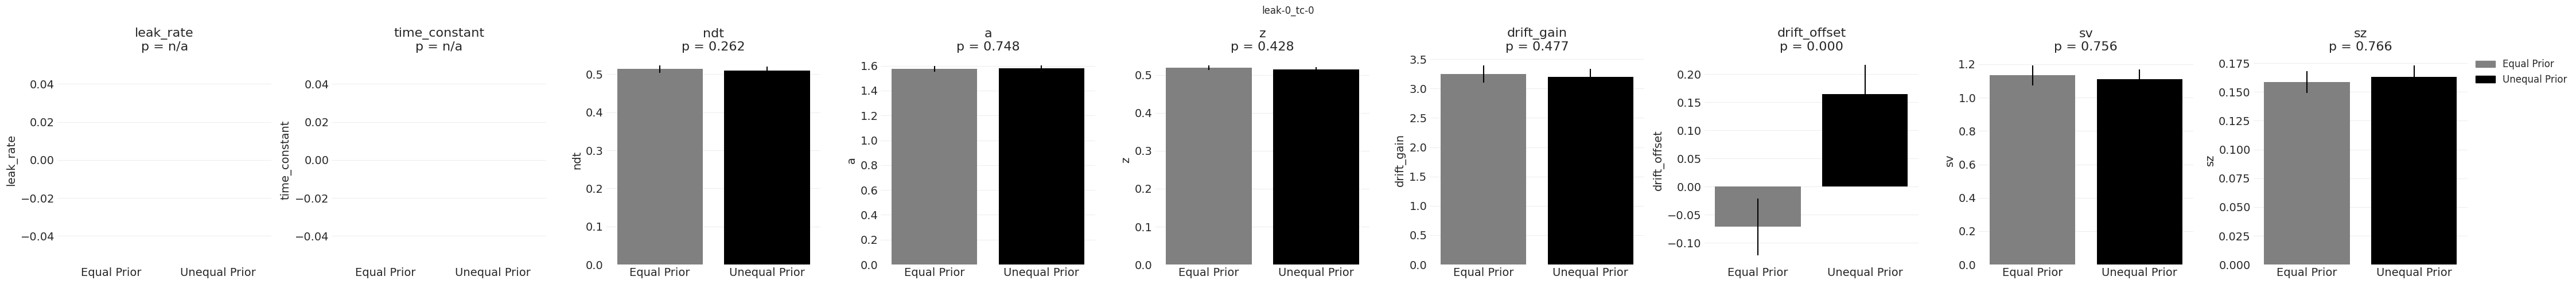

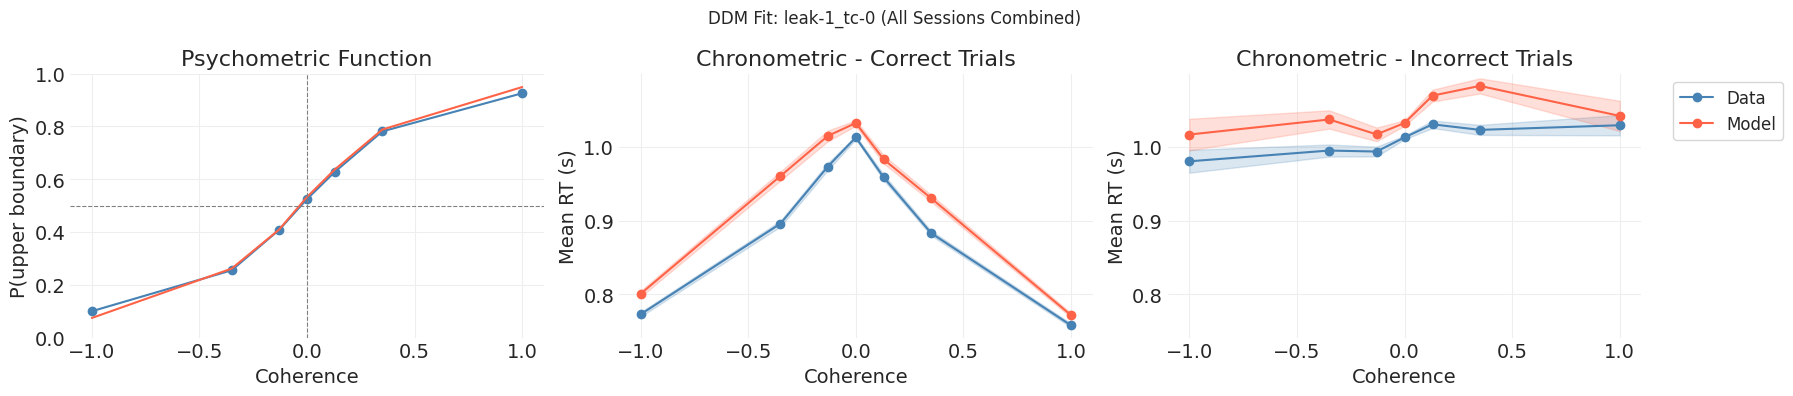

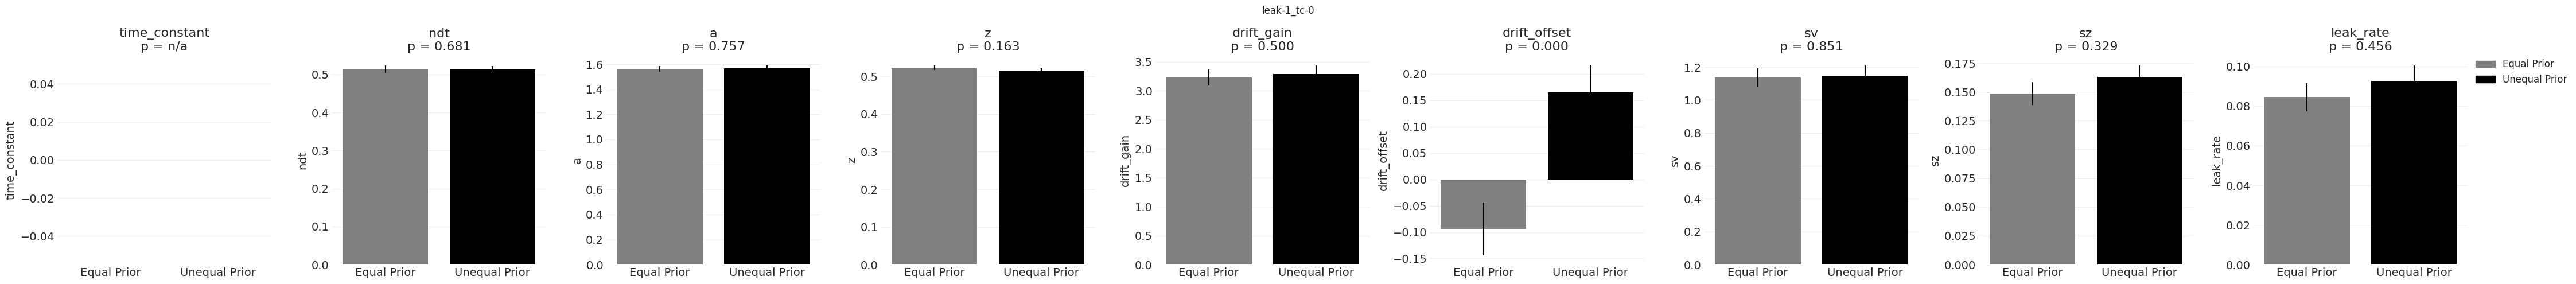

In [17]:
figures_list = []
param_figures_list = []
fitted_param_dict = {}

plot_individual_fits = False

for model_dir in models:
    fit_fig, fitted_params = load_and_plot_model(model_dir, behavior_df, plot_individual_fits)
    param_fig = plot_param_comparison(fitted_params, model_name=model_dir.name)

    fitted_param_dict[model_dir.name] = fitted_params
    figures_list.append(fit_fig)
    param_figures_list.append(param_fig)

In [20]:
model_names = list(fitted_param_dict.keys())

output_path = "dissemination/ddm/ddm_model_comparison.pptx"
save_figures_to_pptx(figures_list, param_figures_list, model_names, output_path=output_path)

Saved 5 slides → dissemination/ddm/ddm_model_comparison.pptx
